In [ ]:
# Uncomment this if you do not already have WordCloud installed!
#!pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [129]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

np.random.seed(67) # for reproducibility

In [ ]:
# Link Colab to your Google Account
# If you are using Colab, you will need to sign in to Google here!

from google.colab import drive
drive.mount('/content/drive') 

# **Section 1: Importing and Data Cleaning**

Before running the code, please download `movies.csv` from the Google Drive link [**here**](https://drive.google.com/drive/folders/1Izp2hQJ9oJig3TowOYx359Rc1vZT_nbP?usp=sharing) and place the data into your Google Drive.

-----------------------

> **Your role:** You are a data analyst helping a streaming platform understand its movie catalogue.

The streaming platform is reviewing its movie catalogue before deciding what content to promote, acquire, or recommend. We need to understand the catalogue and identify patterns, while being careful not to make claims the data cannot support.

Load in the movies dataset:

In [ ]:
# Modify the path according to where your data is stored in your computer / Google Drive
movies = pd.read_csv("data/movies.csv")
# Uncomment the below line and comment out the above line if you are using Google Colab
#movies = pd.read_csv("drive/MyDrive/[For Participants] SDS EDA Workshops AY2627 Data/movies.csv")

> **Guiding Question 1:** What exactly is in this catalogue, and can we trust the data before using it?

Look at the first few rows using `.head()`. You can specify the number of rows within the brackets!

In [131]:
movies.head()

,budget,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,primary_genre,secondary_genre,tertiary_genre
0,237000000,http://www.avatarmovie.com/,19995,culture clash|future|space war|space colony|so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,Ingenious Film Partners|Twentieth Century Fox ...,United States of America|United Kingdom,...,162.0,English|Español,Released,Enter the World of Pandora.,Avatar,7.2,11800,Action,Adventure,Fantasy
1,300000000,http://disney.go.com/disneypictures/pirates/,285,ocean|drug abuse|exotic island|east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,Walt Disney Pictures|Jerry Bruckheimer Films|S...,United States of America,...,169.0,English,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Adventure,Fantasy,Action
2,245000000,http://www.sonypictures.com/movies/spectre/,206647,spy|based on novel|secret agent|sequel|mi6|bri...,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,Columbia Pictures|Danjaq|B24,United Kingdom|United States of America,...,148.0,Français|English|Español|Italiano|Deutsch,Released,A Plan No One Escapes,Spectre,6.3,4466,Action,Adventure,Crime
3,250000000,http://www.thedarkknightrises.com/,49026,dc comics|crime fighter|terrorist|secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,Legendary Pictures|Warner Bros.|DC Entertainme...,United States of America,...,165.0,English,Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Action,Crime,Drama
4,260000000,http://movies.disney.com/john-carter,49529,based on novel|mars|medallion|space travel|pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,...,132.0,English,Released,"Lost in our world, found in another.",John Carter,6.1,2124,Action,Adventure,Science Fiction


In [132]:
movies.shape # returns (rows, columns)

(4802, 22)

In [133]:
# how many cells contain null values?
print(movies.isna().sum())

# are there any duplicated rows?
print(f"Duplicates: {movies.duplicated().sum()}")

budget                     0
homepage                3090
id                         0
keywords                 411
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies     350
production_countries     173
release_date               0
revenue                    0
runtime                    2
spoken_languages          86
status                     0
tagline                  843
title                      0
vote_average               0
vote_count                 0
primary_genre             27
secondary_genre          927
tertiary_genre          2417
dtype: int64
Duplicates: 0


Homepage and tagline aren't particularly helpful to us, so we can remove those columns entirely:


In [134]:
movies[['homepage','tagline']].head(2)

,homepage,tagline
0,http://www.avatarmovie.com/,Enter the World of Pandora.
1,http://disney.go.com/disneypictures/pirates/,"At the end of the world, the adventure begins."


In [135]:
movies.drop(['homepage','tagline'], axis = 1, inplace = True)

*What should we do with columns with missing data?*

For movie `runtime`, we could consider using the mean/median. We should inspect the distribution first. If runtimes are **highly skewed or contain extreme values**, the **median may be more appropriate**.

In [136]:
print(movies['runtime'].describe())

count    4800.000000
mean      106.898125
std        22.561593
min         0.000000
25%        94.000000
50%       103.000000
75%       118.000000
max       338.000000
Name: runtime, dtype: float64


Wait... notice anything odd about any of the values above?

In [137]:
# Activity: Checking out anomalies

print(f"Number of films with a runtime of 0: {(movies["runtime"] == 0).sum()}")

movies = movies[movies["runtime"] != 0]

print(f"{movies["runtime"].min()} minutes is now the shortest film in our dataset")

Number of films with a runtime of 0: 34
14.0 minutes is now the shortest film in our dataset


Going back to the `runtime` missing values, we can see that the mean is slightly higher than the median. Also, the maximum value (338 minutes) is much higher than the 75th percentile (118 minutes).

Hence, even without a graph, we can see that the data is right-skewed.

But here's a plot of the data using a histogram (more on visualisation to come later!) to confirm that.

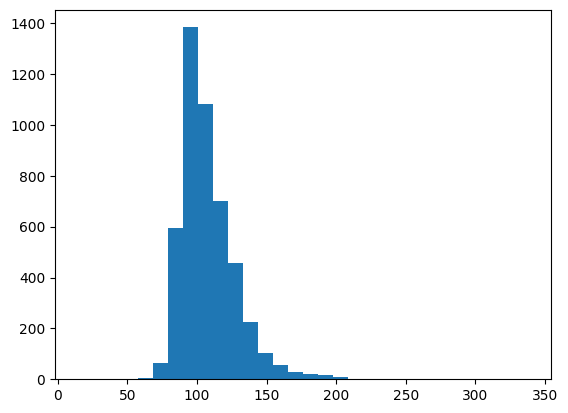

In [138]:
plt.hist(
    movies["runtime"],
    bins=30
); plt.show()

In this case, it would be better to use the **median** to fill in the missing values for `runtime`.

In [139]:
movies['runtime'] = movies['runtime'].fillna(movies['runtime'].median())

print(f"Median runtime is {movies['runtime'].median()} minutes!")

Median runtime is 104.0 minutes!


With the `genre` columns, we don't know what the missing movie genres are, so assigning a specific genre (e.g. using mode) could introduce false information.

Using "Unknown" preserves those observations while clearly indicating that the genre is unavailable.

In [140]:
genre_cols = [
    'primary_genre',
    'secondary_genre',
    'tertiary_genre'
]

movies[genre_cols] = movies[genre_cols].fillna('Unknown')

For columns like `keywords`, `production_companies/countries`, `overview` and `spoken_languages`, we could leave the null values as they are, since it's valid not to have any keywords, production companies, or languages.

Here, we replace them with an empty string `''` instead, to allow us to treat all entries as text when performing text-based analysis further down the line.

In [141]:
text_cols = [
    'keywords',
    'production_companies',
    'production_countries',
    'spoken_languages',
    'overview'
]

movies[text_cols] = movies[text_cols].fillna('')

Let's check for null values again:

In [142]:
print(movies.isna().sum())

budget                  0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
status                  0
title                   0
vote_average            0
vote_count              0
primary_genre           0
secondary_genre         0
tertiary_genre          0
dtype: int64


`.info()` is a quick way to see the column names, number of observations and data types in your dataframe.

In [143]:
print(movies.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4768 entries, 0 to 4801
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4768 non-null   int64  
 1   id                    4768 non-null   int64  
 2   keywords              4768 non-null   object 
 3   original_language     4768 non-null   object 
 4   original_title        4768 non-null   object 
 5   overview              4768 non-null   object 
 6   popularity            4768 non-null   float64
 7   production_companies  4768 non-null   object 
 8   production_countries  4768 non-null   object 
 9   release_date          4768 non-null   object 
 10  revenue               4768 non-null   int64  
 11  runtime               4768 non-null   float64
 12  spoken_languages      4768 non-null   object 
 13  status                4768 non-null   object 
 14  title                 4768 non-null   object 
 15  vote_average          4768

Date columns like `release_date` should be changed to datetime format instead of a string.

In [144]:
movies["release_date"] = pd.to_datetime(movies['release_date']); movies['release_date'].info()

<class 'pandas.core.series.Series'>
Index: 4768 entries, 0 to 4801
Series name: release_date
Non-Null Count  Dtype         
--------------  -----         
4768 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 74.5 KB


## **Exploring the Data**

As the data has generally been cleaned of null values, we can start examining the columns of the dataset more closely!

In [145]:
print(movies.shape) # remaining rows/cols

(4768, 20)


In [146]:
# What is the average/mean vote count for all films?
print(f"Mean vote count: {movies['vote_count'].mean().round(2)}")

# What is the most budget of a film in this dataset?
print(f"Max budget: ${movies["budget"].max()}")

Mean vote count: 695.26
Max budget: $380000000


To get an overall summary, an easier way is to use `.describe()`:

In [147]:
movies.describe()

,budget,id,popularity,release_date,revenue,runtime,vote_average,vote_count
count,4.768000e+03,4768.00000,4768.000000,4768,4.768000e+03,4768.000000,4768.000000,4768.000000
mean,2.925709e+07,56003.71057,21.647404,2002-12-09 02:11:58.791946368,8.286394e+07,107.659186,6.112332,695.261745
min,0.000000e+00,5.00000,0.000372,1916-09-04 00:00:00,0.000000e+00,14.000000,0.000000,0.000000
25%,9.919215e+05,8987.75000,4.838697,1999-06-15 12:00:00,0.000000e+00,94.000000,5.600000,56.000000
50%,1.500000e+07,14456.50000,13.149014,2005-09-16 00:00:00,1.953216e+07,104.000000,6.200000,239.000000
75%,4.000000e+07,57159.75000,28.532272,2011-01-29 12:00:00,9.371813e+07,118.000000,6.800000,742.000000
max,3.800000e+08,459488.00000,875.581305,2017-02-03 00:00:00,2.787965e+09,338.000000,10.000000,13752.000000
std,4.079599e+07,87439.55403,31.881465,NaN,1.633010e+08,20.745206,1.147306,1237.700008


> **Guiding question 2:** Is the catalogue dominated by short (less than 60 mins), medium (60 to 120 mins), long (120 mins to 180 mins), or very long films (180 mins or longer)?

It is possible to split numerical data into categories if it helps with our analysis.

Here, we want to investigate the length of movies in the dataset. We can create a new column called `length_category` that categorises the movies based on their runtime.

In [148]:
bins = [0, 60, 120, 180, float('inf')] # FYI: the lower bound for "Short" will be 14 here, as that's the shortest movie length
labels = ['Short', 'Medium', 'Long', 'Very Long']

movies['runtime_category'] = pd.cut(
    movies['runtime'],
    bins=bins,
    labels=labels,
    right=False # upper bound is non-inclusive, e.g. 0 <= runtime < 60
)

movies['runtime_category'].value_counts()

runtime_category
Medium       3687
Long         1026
Very Long      47
Short           8
Name: count, dtype: int64

In [149]:
movies['runtime_category'].value_counts(normalize = True) * 100

runtime_category
Medium       77.328020
Long         21.518456
Very Long     0.985738
Short         0.167785
Name: proportion, dtype: float64

77% of films are between 60 and 120 minutes long (medium length).

> **Guiding question 3a:** How many genres are there, and how many films of each primary genre are there?

In [150]:
print(movies['primary_genre'].nunique()) # how many unique categories are there?

print(movies['primary_genre'].unique()) # what are these categories?

21
['Action' 'Adventure' 'Fantasy' 'Animation' 'Science Fiction' 'Drama'
 'Thriller' 'Family' 'Comedy' 'History' 'War' 'Western' 'Romance' 'Crime'
 'Mystery' 'Horror' 'Documentary' 'Music' 'TV Movie' 'Unknown' 'Foreign']


In [151]:
print(movies['primary_genre'].value_counts())

primary_genre
Drama              1204
Comedy             1038
Action              753
Adventure           339
Horror              294
Crime               194
Thriller            193
Animation           123
Fantasy             117
Romance             105
Science Fiction      96
Documentary          88
Family               54
Mystery              41
Music                33
Western              27
History              25
War                  23
Unknown              15
TV Movie              4
Foreign               2
Name: count, dtype: int64


### **Grouping, Sorting & Aggregation**

By grouping the films into their respective categories, we can look at how the groups compare to one another.

> **Guiding question 3b:** Which 5 primary genres have the highest average popularity?

In [152]:
movies.groupby('primary_genre')['popularity'].mean()

primary_genre
Action             28.520927
Adventure          39.057579
Animation          35.359647
Comedy             14.897362
Crime              19.974365
Documentary         3.587666
Drama              16.133804
Family             37.479863
Fantasy            33.821786
Foreign             0.074425
History            19.034787
Horror             19.793994
Music              11.025917
Mystery            23.744675
Romance            18.995591
Science Fiction    42.053748
TV Movie            5.627443
Thriller           21.985947
Unknown             0.221582
War                24.022477
Western            22.306204
Name: popularity, dtype: float64

... and then sort this to find the 5 most popular genres!

In [153]:
# sort films by vote average, from highest to lowest
movies.groupby('primary_genre')['popularity'].mean().sort_values(ascending=False).head().round(2)

primary_genre
Science Fiction    42.05
Adventure          39.06
Family             37.48
Animation          35.36
Fantasy            33.82
Name: popularity, dtype: float64

> **Guiding Question 4:** What are the most common release years in the catalogue?

Look more closely at **release_date**:

In [154]:
movies['release_date'].sample(10)

3231   2006-02-03
4330   2008-06-17
3444   1978-07-07
3782   2012-07-02
1871   2007-03-22
3845   2010-10-29
2018   1998-07-15
3737   1968-10-01
2066   1982-06-13
1186   2009-08-26
Name: release_date, dtype: datetime64[ns]

We could add a `Year` column to make working with the data easier.

In [155]:
movies['year'] = movies['release_date'].dt.year; movies['year'].head()

0    2009
1    2007
2    2015
3    2012
4    2012
Name: year, dtype: int32

In [156]:
movies.groupby('year')['year'].count().sort_values(ascending=False).head()

year
2009    247
2006    234
2014    231
2013    228
2008    226
Name: year, dtype: int64

The 5 most featured years are 2009, 2006, 2014, 2013, and 2008.

> **Guiding question 5:** How does the runtime of movies vary across genres? What is the standard deviation of runtimes?

In [157]:
movies.groupby('primary_genre')['runtime'].agg(
    ['count', 'mean', 'std']
).sort_values('mean', ascending=False).round(2)

,count,mean,std
primary_genre,,,
History,25,133.96,30.59
War,23,131.61,30.89
Western,27,117.93,24.28
Drama,1204,115.80,23.79
Adventure,339,113.06,22.35
Crime,194,112.72,23.73
TV Movie,4,110.50,46.35
Action,753,109.20,18.50
Science Fiction,96,109.03,18.01


# **Section 2: Data Visualisation**

In this section, we will learn how to plot a few different visualisations using two different sets of data `movies.csv` and `immigrants.csv`. Do ensure that **both** sets of data are present in your workspace before beginning!

-------

## **Correlation Matrix**


**Best For:** Exploring Relationships Between Two Different Variables

**What to look out for?**
+ Which variables have the strongest relationships?
+ Is the relationship positive or negative?
+ Are the variables highly correlated with each other?

Note that correlation matrices only work on **numeric** variables only, and hence we will need to subset the columns for only numeric variables first before plotting!

If you would like to test the correlation between two **categorical** variables, you can look into the following instead (but it will not be covered in this workshop):
+ Cramér's V
+ Theil's U (Uncertainty Coefficient)
+ Phi Coefficient (for 2x2 categorical variables)

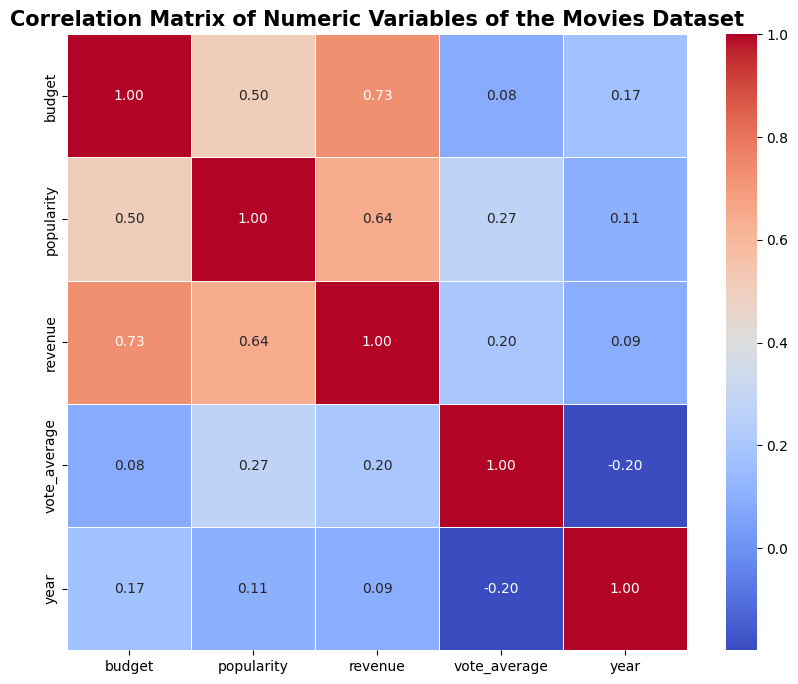

In [158]:
movies.dtypes # check for which columns contain numeric values

# let's select four numeric columns to observe correlation
numeric_columns = ["budget", "popularity", "revenue", "vote_average", "year"] 
movies_numeric = movies[numeric_columns]

# calculate correlation matrix
correlation_matrix = movies_numeric.corr()

# plot correlation matrix
plt.figure(figsize = (10, 8))

sns.heatmap(
    correlation_matrix,
    cmap = "coolwarm",
    annot = True,
    fmt = ".2f",
    linewidths = 0.5
)

plt.title("Correlation Matrix of Numeric Variables of the Movies Dataset",
          fontweight = "bold", fontsize = 15)
plt.show()

## **Word Cloud**

This is a **domain-specific** type of plot that works best when we have word information present in the dataset (e.g. reviews, movie descriptions). Here, we will plot a word cloud of the words specified in the `keywords` column!

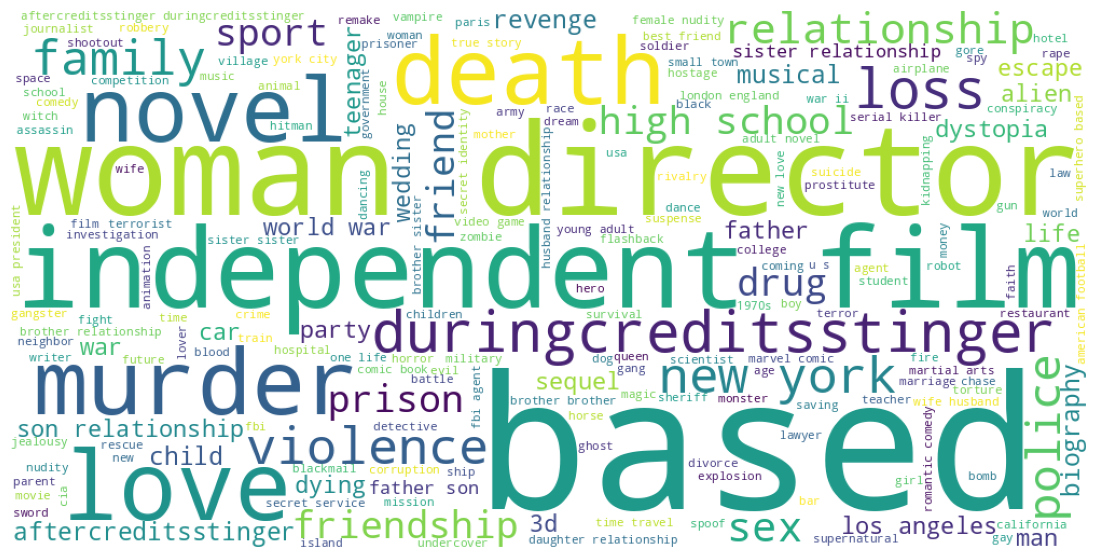

In [159]:
# Split each movie's keywords into a list, using '|' as a separator
movies['keywords'] = movies['keywords'].str.split('|')

# Flatten the lists of keywords into one list, and remove any empty keywords
all_keywords = [
    keyword
    for keywords in movies['keywords']
    for keyword in keywords
    if keyword
]

# Join all the keywords into one single string, separated by spaces
# E.g. "love based novel relationship dystopia ..."
combined_text = " ".join(all_keywords)

# Create a word cloud with the combined keyword text
wordcloud = WordCloud(
    width = 1000,
    height = 500,
    background_color="white"
).generate(combined_text)

# Display the word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### **Immigrants Dataset**

For the next few plots that we will be drawing, we will be using the `immigrants.csv` dataset. Here is the data dictionary:

|Variable|Description|Data Type|
|--|--|--|
|**Entity**|Name of Country or Territory|`string`|
|**Code**|Three-Letter Country Code (e.g. `AFG` for Afghanistan)|`string`|
|**Year**|Year of Observation|`int`|
|**Share of the population that was born in another country**|The percentage of the population who were born abroad|`float`|
|**Total number of international immigrants**|Estimated total number of international immigrants living in a country that year|`int`|
|**GDP per capita**|Gross domestic product per capita in a given country and year in constant international dollars. Values have been adjusted for inflation and cost of living.|`float`|

In [ ]:
### Let's do some simple exploration of the dataset
# Modify the path according to where your data is stored in your computer / Google Drive
immigrants = pd.read_csv("data/immigrants.csv")
# Uncomment the below line and comment out the above line if you are using Google Colab
#movies = pd.read_csv("drive/MyDrive/[For Participants] SDS EDA Workshops AY2627 Data/immigrants.csv")

immigrants.head()

,Entity,Code,Year,Share of the population that was born in another country,Total number of international immigrants,GDP per capita
0,Afghanistan,AFG,2000,0.377128,75917,1617.8264
1,Afghanistan,AFG,2005,0.357777,87314,1908.1147
2,Afghanistan,AFG,2010,0.361603,102276,2848.5862
3,Afghanistan,AFG,2015,1.003294,339432,2967.6921
4,Afghanistan,AFG,2020,0.368830,144098,2769.6858


In [161]:
### Rename the column headers to something simpler
immigrants.columns = ["country", "code", "year", "share", "total_immigrants", "gdp_per_capita"]
immigrants.head()

,country,code,year,share,total_immigrants,gdp_per_capita
0,Afghanistan,AFG,2000,0.377128,75917,1617.8264
1,Afghanistan,AFG,2005,0.357777,87314,1908.1147
2,Afghanistan,AFG,2010,0.361603,102276,2848.5862
3,Afghanistan,AFG,2015,1.003294,339432,2967.6921
4,Afghanistan,AFG,2020,0.368830,144098,2769.6858


For simplicity, we will reduce our scope of the dataset to focus on immigrant data in **European Countries** only. The countries considered are specified in the `europe` list below.

Of course, feel free to explore the data for countries of other continents of your own time after the workshop!

In [162]:
##### Let's reduce the scope of our observations to EUROPEAN countries only
europe = [
    "Albania", "Austria", "Belgium", "Bosnia and Herzegovina",
    "Bulgaria", "Croatia", "Czechia", "Denmark", "Estonia",
    "Finland", "France", "Germany", "Greece", "Iceland",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
    "Malta", "Moldova", "Montenegro", "Netherlands",
    "North Macedonia", "Norway", "Poland", "Portugal",
    "Romania", "San Marino", "Serbia", "Slovakia", "Slovenia",
    "Spain", "Sweden", "Switzerland", "Ukraine", "United Kingdom"
]

europe_immigrants = immigrants[immigrants["country"].isin(europe)]

europe_immigrants.head()

,country,code,year,share,total_immigrants,gdp_per_capita
6,Albania,ALB,2000,2.422344,76695,6581.639
7,Albania,ALB,2005,2.104540,64739,8963.804
8,Albania,ALB,2010,1.802288,52784,11828.375
9,Albania,ALB,2015,1.795019,52031,13156.332
10,Albania,ALB,2020,1.699540,48810,14662.796


## **Line Plot**

**Best For:** Showing Trends Over Time

**Variables Needed**
+ Horizontal Axis: Ordered / Time Variable
+ Vertical Axis: Numerical Variable

**What to look out for?**
+ Is there an upward or downward trend?
+ Are there any peaks or dips?
+ Are there any sudden changes or repeating patterns?

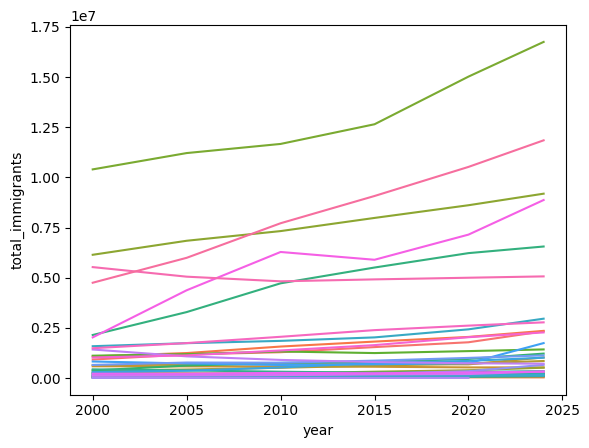

In [163]:
##### Let's begin with a simple line plot first
sns.lineplot(
    data = europe_immigrants,
    x = "year",
    y = "total_immigrants",
    hue = "country",
    legend = False
)

plt.show()

##### What's the issue?
# Too many lines! Viewer will not know what to focus on.
# Let's improve on this plot iteratively.

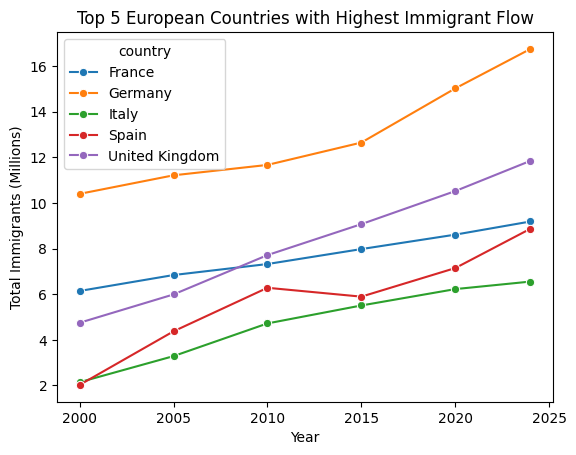

In [164]:
##### Let's make our plot more interesting instead of trying to look at all European countries.
##### We'll focus on only the top 5 European countries with the highest total immigrants in 2024.

##### The following code extracts the top 5 European countries in 2024
# This subsets for 2024 observations of each country
europe_2024 = europe_immigrants[europe_immigrants["year"] == 2024]

# This sorts the total_immigrants column and extracts the top 5 countries with highest total_immigrants
top_5_europe = europe_2024.sort_values("total_immigrants", ascending = False).head(5)["country"]

# Obtains the immigrant information of the top 5 countries from 2000 - 2024
top_5_europe_immigrants = europe_immigrants[europe_immigrants["country"].isin(top_5_europe)].copy()
top_5_europe_immigrants["total_immigrants_mill"] = top_5_europe_immigrants["total_immigrants"] / 1e6  

# Plot the line graph
sns.lineplot(
    data = top_5_europe_immigrants,
    x = "year",
    y = "total_immigrants_mill",
    hue = "country",
    marker = "o"
)

# Add nice plot elements
plt.xlabel("Year")
plt.ylabel("Total Immigrants (Millions)")
plt.title("Top 5 European Countries with Highest Immigrant Flow")

plt.show()

##### Looks great, but how can we do better?
# We can probably add gridlines to help guide readers to axes values.
# We can probably also move the country names to the right of the lines
# to make it easier for a viewer to match the country to the line.

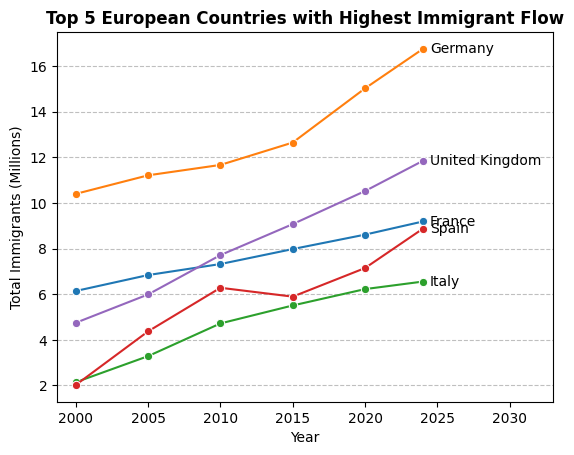

In [165]:
##### Let's put the countries in the legend to the side of the graphs
# Plot the graph
ax = sns.lineplot(
    data = top_5_europe_immigrants,
    x = "year",
    y = "total_immigrants_mill",
    hue = "country",
    marker = "o",
    legend = False
)

# Add country names at the end of each line
for country, country_df in top_5_europe_immigrants.groupby("country"):
    last_row = country_df.sort_values("year").iloc[-1]

    plt.text(
        last_row["year"] + 0.5,
        last_row["total_immigrants_mill"],
        country,
        va="center"
    )

# Add nice plot elements
plt.xlabel("Year")
plt.ylabel("Total Immigrants (Millions)")
plt.grid(True, axis = "y", alpha = 0.8, linestyle = "--")
plt.title("Top 5 European Countries with Highest Immigrant Flow", fontweight = "bold")

# Give labels a bit of breathing room on the right
plt.xlim(1998.7, 2033)

plt.show()

## **Choropleth Map**

**Best For:** Comparing Geographical Areas

**Variables Needed**
+ Geographical Variable: Region / Location
+ Numerical Variable: Value Associated with Each Region

**What to look out for?**
+ Which areas have higher or lower values?
+ Are there any geographical patterns or clusters?
+ Are there any regional outliers?

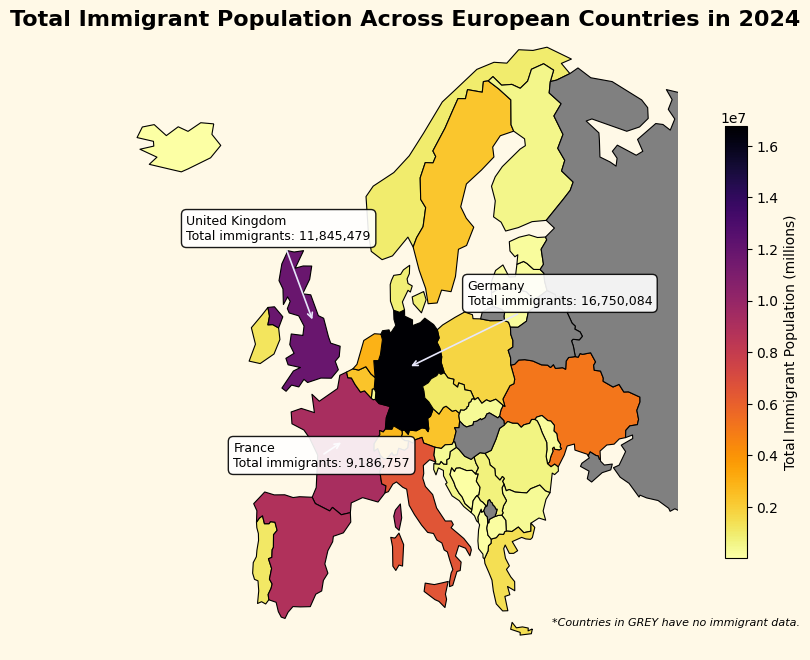

In [166]:
##### Loading in European Countries Boundaries and Merging Data
# Load Shapes of World Boundaries
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

# Consider only European countries and their boundaries
europe_base = world[world["CONTINENT"] == "Europe"]

# Merge 2010 Immigration Data onto European Country Boundaries
europe_map = europe_base.merge(
    europe_2024,
    left_on="ADM0_A3",
    right_on="code",
    how="left"
)

##### Annotation for Top 3 European Countries with Highest Immigration
# Countries to Annotate (Top 3)
highlight_countries = ["Germany", "United Kingdom", "France"]
highlight = europe_map[europe_map["NAME"].isin(highlight_countries)].copy()

# Select a point in the country's polygon
highlight["label_point"] = highlight.geometry.representative_point()

# Chooses where the label boxes should appear
# The values are stored in the form (longitude, latitude), and can be modified if necessary
label_positions = {
    "United Kingdom": (-18, 60),
    "France": (-12, 46),
    "Germany": (18, 56)
}

##### Plot the Choropleth Map
fig, ax = plt.subplots(figsize = (12, 8),
                       facecolor = "#fff9e7")

plot = europe_map.plot(
    column = "total_immigrants",
    cmap = "inferno_r",  # colourblind-friendly palette!
    linewidth = 0.8,
    edgecolor = "black",
    legend = True,
    legend_kwds = {
        "label": "Total Immigrant Population (millions)",
        "shrink": 0.7
    },
    missing_kwds = {
        "color": "grey",
        "edgecolor": "black",
    },
    ax=ax
)

# Adds country annotations to the figure
for _, row in highlight.iterrows():
    country = row["NAME"]
    immigrants = row["total_immigrants"]

    # point inside the country
    x = row["label_point"].x
    y = row["label_point"].y

    # where the textbox should go
    box_x, box_y = label_positions[country]

    ax.annotate(
        f"{country}\nTotal immigrants: {int(immigrants):,}",
        xy = (x, y),               
        xytext = (box_x, box_y),   
        textcoords = "data",
        ha = "left",
        va = "center",
        fontsize = 9,
        bbox = dict(
            boxstyle = "round,pad=0.4",
            facecolor = "white",
            edgecolor = "black",
            alpha = 0.9
        ),
        arrowprops = dict(
            arrowstyle = "->",
            color = "lavender",
            lw = 1.2
        )
    )

# Zoom the plot into Europe
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

# Set the title
ax.set_title(
    "Total Immigrant Population Across European Countries in 2024",
    fontweight = "bold",
    fontsize = 16
)

# Turn off the x and y-axis
ax.axis("off")

# Adds a caption specifying what the colour "grey" means
plt.figtext(
    0.64, 0.14,
    "*Countries in GREY have no immigrant data.",
    ha = "left",
    fontsize = 8,
    style = "italic"
)

plt.show()

# **Section 3: Working with LLMs**

In this section, we will be working with the Food Delivery dataset `food_delivery.csv` which is likewise available at our Google Drive link [here](https://drive.google.com/drive/folders/1Izp2hQJ9oJig3TowOYx359Rc1vZT_nbP?usp=sharing).

We will learn how to take advantage of LLMs to assist in the EDA process through LLM-Assisted Coding, and good LLM usage principles so that we can make the most out of our visualisations!

------

## **Food Delivery Dataset**

### **Understanding the Dataset**

Before analysing individual variables, let's first inspect the dataset with the methods taught in the first section! As a quick refresher:

+ `df.head()` gives us a quick preview of the observations and columns.
+ `df.info()` shows the number of rows, column names, data types and non-missing values. This helps us identify possible data-quality issues.
+ `df.describe()` provides basic summary statistics for numerical variables.

In [ ]:
# Modify the path according to where your data is stored in your computer / Google Drive
df = pd.read_csv("data/food_delivery.csv")
# Uncomment the below line and comment out the above line if you are using Google Colab
#movies = pd.read_csv("drive/MyDrive/[For Participants] SDS EDA Workshops AY2627 Data/food_delivery.csv")

# Preview the dataset
display(df.head())

# Check columns, data types and missing values
df.info()

# View summary statistics for numerical variables
display(df.describe())

,order_id,distance_km,delivery_time_min,order_value_sgd,vehicle_type,traffic_level,weather,time_of_day,area,customer_rating
0,SG10001,6.5,40,37.18,Car,Low,Clear,Evening,Central,4.7
1,SG10002,8.5,45,32.93,Bicycle,Low,Clear,Evening,North-East,NaN
2,SG10003,5.8,39,77.56,Bicycle,Medium,Clear,Morning,Central,3.8
3,SG10004,5.3,35,35.94,Motorcycle,Low,NaN,Morning,North,4.8
4,SG10005,9.2,50,30.41,Bicycle,Low,Cloudy,Evening,West,4.3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   order_id           602 non-null    object
 1   distance_km        604 non-null    object
 2   delivery_time_min  603 non-null    object
 3   order_value_sgd    603 non-null    object
 4   vehicle_type       604 non-null    object
 5   traffic_level      598 non-null    object
 6   weather            577 non-null    object
 7   time_of_day        604 non-null    object
 8   area               604 non-null    object
 9   customer_rating    568 non-null    object
dtypes: object(10)
memory usage: 47.3+ KB


,order_id,distance_km,delivery_time_min,order_value_sgd,vehicle_type,traffic_level,weather,time_of_day,area,customer_rating
count,602,604,603,603,604,598,577,604,604,568
unique,598,136,75,535,9,7,7,8,5,28
top,SG10133,4.2,47,7,Motorcycle,Medium,Clear,Evening,Central,5
freq,2,11,23,18,328,260,318,217,165,165


### **Good Prompt Example**

Look over the code again to ensure there are no errors. Review the code itself to make sure it is doing what you want it to do. In this case, there are no errors and the values shown are in line with the dataset.

**Prompt:**

> I want to understand the distribution of `delivery_time_min`. Write pandas code to calculate its mean, median, standard deviation, minimum, maximum, and quartiles. Do not modify the data or calculate the values yourself. Provide the code only. I want even those with different formats to included, such as those values with units. For blank data, ignore and do not include them in the calculation. Include outliers. Explain the code.  

In [168]:
# Temporarily extract the numerical part of delivery_time_min
delivery_time = pd.to_numeric(
    df['delivery_time_min']
    .astype('string')
    .str.extract(r'([-+]?\d*\.?\d+)', expand=False),
    errors='coerce'
)

# Calculate summary statistics
print("Mean:", delivery_time.mean())
print("Median:", delivery_time.median())
print("Standard Deviation:", delivery_time.std())
print("Minimum:", delivery_time.min())
print("Maximum:", delivery_time.max())
print("Quartiles:")
print(delivery_time.quantile([0.25, 0.50, 0.75]))

Mean: 43.86733001658375
Median: 42.0
Standard Deviation: 14.853514321864878
Minimum: 12
Maximum: 167
Quartiles:
0.25    34
0.50    42
0.75    52
Name: delivery_time_min, dtype: Int64


### **Scatterplot**

### **Bad Prompt Example**

The code below throws an error due to unclarified parameters / boundaries in the data.

**Prompt:**
> Make a scatterplot of distance and delivery time.

TypeError: 'value' must be an instance of str or bytes, not a float

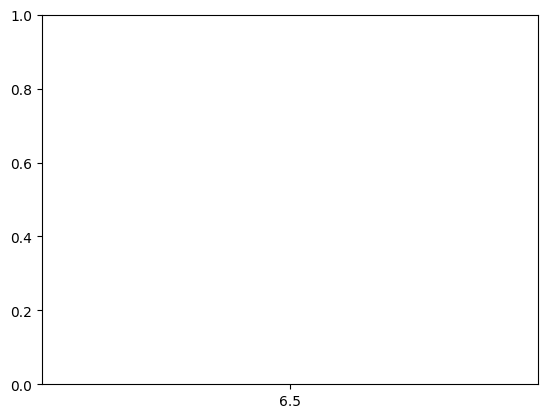

In [169]:
##### Running this code will raise a TypeError as expected!

# Create scatterplot
plt.scatter(df["distance_km"], df["delivery_time_min"])

# Labels and title
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.title("Distance vs Delivery Time")

plt.show()

### **Good Prompt Example**

The code given below works immediately as the task, context and parameters are provided clearly. But you should still check the code to make sure there is fulfills your goals.

Prompt:
> I want to investigate the relationship between `distance_km` and `delivery_time_min`. Write Matplotlib code for a scatterplot with `distance_km` on the x-axis and `delivery_time_min` on the y-axis. I want even those with different formats to included, such as those values with units. For blank data, ignore and do not include them in the calculation. Do not modify the data, and explain the code.

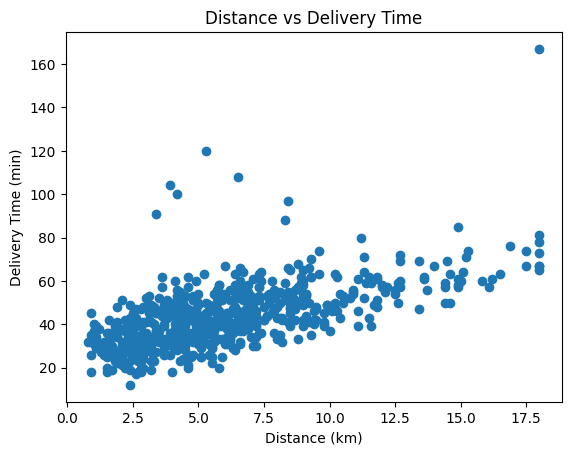

In [170]:
##### Improving the prompt fixes the issue!

# Temporarily extract the numerical part of each column
distance = pd.to_numeric(
    df['distance_km'].astype('string').str.extract(r'([-+]?\d*\.?\d+)', expand=False),
    errors='coerce'
)

delivery_time = pd.to_numeric(
    df['delivery_time_min'].astype('string').str.extract(r'([-+]?\d*\.?\d+)', expand=False),
    errors='coerce'
)

# Keep only rows where both values are available
valid = distance.notna() & delivery_time.notna()

# Create the scatterplot
plt.scatter(distance[valid], delivery_time[valid])

# Label the axes
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')

# Add a title
plt.title('Distance vs Delivery Time')

# Display the plot
plt.show()

### **Bar Graph**

### **Bad Prompt Example**

This error happens because `delivery_time_min` is being stored by `pandas` as a string (`str` or `object`) rather than as a numeric column.

**Prompt:**
> Give me the code to create a bar plot comparing delivery time and traffic.

In [171]:
##### Running this code will raise a TypeError as expected!

# Calculate average delivery time for each traffic level
avg_delivery = df.groupby("traffic_level")["delivery_time_min"].mean()

# Create bar plot
plt.bar(avg_delivery.index, avg_delivery.values)

# Labels and title
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by Traffic Level")

plt.show()

TypeError: agg function failed [how->mean,dtype->object]

### **Good Prompt Example**

**Prompt:**

> Compare the mean delivery_time_min across traffic_level. Write Matplotlib code for a bar plot ordered Low, Medium, High. Use the latest Matplotlib version. Label the x axis with traffic level and the y axis with delivery time. I want even those with different formats to included, such as high and HIGH being together. For blank data, ignore and do not include them in the calcultion. Do not modify the data, and explain the code.

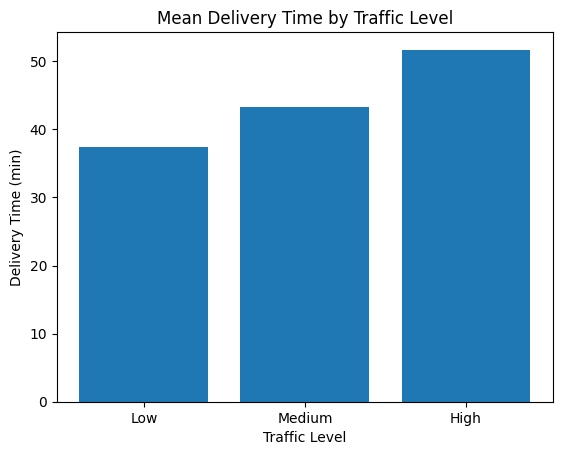

In [172]:
##### Improving the prompt fixes the issue!

# Required order
traffic_order = ['Low', 'Medium', 'High']

# Clean up delivery_time_min column!
df['delivery_time_min'] = (
    df['delivery_time_min']
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

# Calculate mean delivery time for each traffic level
# .str.strip() removes accidental spaces
# .str.lower() makes the comparison case-insensitive
mean_delivery = [
    df.loc[
        df['traffic_level'].str.strip().str.lower() == level.lower(),
        'delivery_time_min'
    ].mean()
    for level in traffic_order
]

# Create the bar plot
plt.bar(traffic_order, mean_delivery)

# Label the axes
plt.xlabel('Traffic Level')
plt.ylabel('Delivery Time (min)')

# Add a title
plt.title('Mean Delivery Time by Traffic Level')

# Display the plot
plt.show()

### **Histogram**

### **Bad Prompt Example**

An error is thrown because the `delivery_time_min` contains mixed data types. Some values are numeric, while others may contain units such as 46 **min**. There may also be blank values.

**Prompt:**
> Make a histogram of delivery time.

TypeError: 'value' must be an instance of str or bytes, not a float

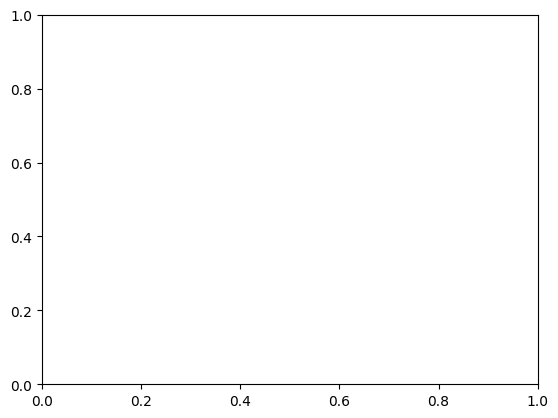

In [ ]:
##### Running this code will raise a TypeError as expected!

# Create histogram
# Modify the path according to where your data is stored in your computer / Google Drive
df = pd.read_csv("data/food_delivery.csv")
# Uncomment the below line and comment out the above line if you are using Google Colab
#movies = pd.read_csv("drive/MyDrive/[For Participants] SDS EDA Workshops AY2627 Data/food_delivery.csv")

plt.hist(df["delivery_time_min"], bins=20)

# Labels and title
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Time")

plt.show()

### **Good Prompt Example**

**Prompt:**
> I want to examine the distribution of `delivery_time_min`. Write Matplotlib code for a histogram with 20 bins with `delivery_time_min` on the x-axis and density frequency on the y axis. I want even those with different formats to included, such as those values with units. For blank data, ignore and do not include them in the calculation. Include outliers. Do not modify the data, and explain the code.


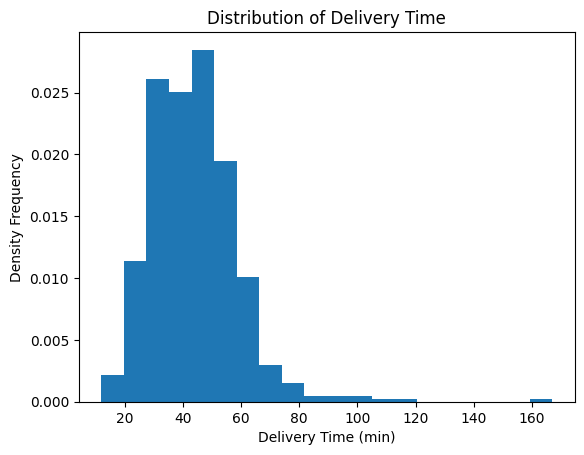

In [174]:
##### Improving the prompt fixes the issue!

# Temporarily extract the numerical part of delivery_time_min
delivery_time = pd.to_numeric(
    df['delivery_time_min']
    .astype('string')
    .str.extract(r'([-+]?\d*\.?\d+)', expand=False),
    errors='coerce'
)

# Remove blank or invalid values only
valid_delivery_time = delivery_time.dropna()

# Create histogram with 20 bins and density frequency
plt.hist(valid_delivery_time, bins=20, density=True)

# Label the axes
plt.xlabel('Delivery Time (min)')
plt.ylabel('Density Frequency')

# Add a title
plt.title('Distribution of Delivery Time')

# Display the histogram
plt.show()

# **Your Turn!**

Now that you've got a feel for exploratory data analysis, it's time to get your hands dirty!

We will be working with a dataset called `olympics.csv`, obtained from Kaggle [here](https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results).

---

The data dictionary below provides a brief description of each variable in the dataset.

`int` = integer | `str` = string | `float` = number with decimals.


|Variable|Meaning|Data Type|
|--|--|--|
|**ID**|Unique identifier for each athlete|`int`|
|**Name**|Athlete's name|`str`|
|**Sex**|Athlete's sex (Male or Female)|`str`|
|**Age**|Athlete's age|`int`|
|**Height**|Athlete's height (cm)|`float`|
|**Weight**|Athlete's weight (kg)|`float`|
|**Team**|Team name|`str`|
|**NOC**|3-letter National Olympic Committee code|`str`|
|**Games**|Year and season of the Games|`str`|
|**Year**|Year of the Games|`int`|
|**Season**|Season of the Games (Summer or Winter)|`str`|
|**City**|Host City of the Games|`str`|
|**Sport**|Name of sport|`str`|
|**Event**|Name of event|`str`|
|**Medal**|Medal won (Gold, Silver, Bronze, or `NA`)|`str`|

# **Your Task**

Using the techniques covered in this workshop - and with some assistance from any LLM of your choice - explore the dataset and see what you can discover!

---

Here's a simple guide to get you started:
+ **Explore and understand the data**. Look out for suspicious / unusual / missing values, and perform any necessary data cleaning.
+ **Come up with one to two questions of interest** that you would like to investigate using the data. Feel free to draw inspiration from the examples we explored earlier.
+ **Create one to two visualisations** that help you to investigate and answer your question(s) of interest.

---

Remember: it's **OKAY** if your visualisations do not reveal a strong or exciting pattern. Finding little to no evidence of a relationship is still a meaningful result.

For example, suppose your question is:
**"Are taller athletes more likely to win a medal?"**

If your analysis does not reveal a clear relationship between height and medals won, report the finding **AS IS**. Do not manipulate the data or alter your visualisations simple to produce the conclusion you expected.

Most importantly, have fun!!! 😊

If you need guidance or help, feel free to approach any of us: See Tien, Natasha, or Jaye.